In [16]:
# =====================================================
# 💼 APP DE INVERSIÓN — CARTERA ÓPTIMA SEGÚN EL PERFIL DE RIESGO
# Challenge de Inteligencia Artificial aplicada a Economía
# Materia: Economía Computacional
# =====================================================
#
# Esta notebook funciona como una pequeña APP: le pregunta al usuario CUÁNTO
# dinero quiere invertir y QUÉ TIPO DE INVERSOR es, y le devuelve una cartera
# de acciones sugerida usando el modelo de Markowitz (optimización de carteras).
#
# 🆕 NOVEDAD: el universo de acciones NO sale de una lista fija. La app lo
#    BUSCA EN VIVO en Yahoo Finance con “screeners” (filtros) por perfil y arma
#    un universo común sobre el que corre todo el análisis y los gráficos.
#
# -----------------------------------------------------
# FICHA DEL ENTREGABLE
# -----------------------------------------------------
# 1) CLASIFICACIÓN DEL PRODUCTO:
#    Herramienta digital interactiva (app de notebook) de apoyo a la decisión
#    financiera, con optimización matemática + interfaz por consola y por botones.
#
# 2) OBJETIVO DEL PROYECTO:
#    Ayudar a un inversor no experto a armar una cartera de acciones acorde a su
#    tolerancia al riesgo, repartiendo automáticamente su capital entre activos.
#
# 3) DESCRIPCIÓN GENERAL:
#    La app busca el universo de acciones en Yahoo Finance, baja sus precios
#    históricos, calcula retorno y riesgo de cada una y resuelve TRES problemas de
#    Markowitz (mínima varianza, máximo Sharpe y máximo retorno), uno por perfil.
#
# 4) FUNCIONALIDAD PROPUESTA:
#    - Búsqueda del universo de acciones EN VIVO en Yahoo Finance (screeners por perfil).
#    - Descarga de precios y cálculo de retornos y covarianzas.
#    - Optimización de la cartera (scipy.optimize) para los 3 perfiles.
#    - Ranking de acciones por perfil y armado de la cartera con las mejores.
#    - Visualizaciones: frontera eficiente, riesgo-retorno y pesos de la cartera.
#    - App interactiva (consola y botones) que reparte el capital del usuario.
#    - Exportación a PDF de la cartera (costo + nominales) y los gráficos (Sección 9).
#
# 5) USUARIOS A QUIENES ESTÁ DIRIGIDO:
#    Inversores minoristas principiantes, estudiantes de finanzas y docentes que
#    quieran mostrar de forma simple la teoría de carteras de Markowitz.
#
# 6) TECNOLOGÍA INVOLUCRADA:
#    Python · numpy · pandas · scipy.optimize (optimización) · matplotlib
#    (gráficos) · yfinance (búsqueda y datos reales) · ipywidgets (botones).
#
# 7) PROTOTIPO FUNCIONAL:
#    Esta misma notebook es el prototipo: se ejecuta de arriba hacia abajo y en
#    las secciones 6 y 7 hace las preguntas y devuelve la cartera.
#
# -----------------------------------------------------
# CÓMO USARLA: ejecutá las celdas en orden (▶ o Shift+Enter).
# ⚠️ La búsqueda en Yahoo necesita internet y una versión reciente de yfinance.
#    Si no hay conexión, la notebook cae sola a datos SIMULADOS para poder correr.
# Ejemplo de aplicación: si ingresás $10.000 y elegís “intermedio”, la app reparte
# esos 10 mil entre las acciones de mejor relación riesgo/retorno y te dice cuántas
# acciones comprar de cada una.
# =====================================================

print("💼 App de Inversión — Cartera óptima por perfil de riesgo")
print("Universo de acciones buscado en Yahoo Finance. Las secciones 6 y 7 son la APP.")


💼 App de Inversión — Cartera óptima por perfil de riesgo
Universo de acciones buscado en Yahoo Finance. Las secciones 6 y 7 son la APP.


In [17]:
# =====================================================
# 1) LIBRERÍAS
# =====================================================
# - numpy / pandas : manejo de datos numéricos y tablas.
# - scipy.optimize : resuelve la optimización de Markowitz (minimizar / maximizar).
# - matplotlib     : gráficos (frontera eficiente, pesos, riesgo-retorno).
# - yfinance       : descarga precios REALES de acciones desde Yahoo Finance.
# (warnings se silencia solo para mantener la salida limpia.)

import os
import time
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt

# yfinance es OPCIONAL: si no está instalado o no hay internet, más abajo la
# notebook usa datos SIMULADOS para poder ejecutarse igual.
try:
    import yfinance as yf
    HAY_YFINANCE = True
except Exception:
    HAY_YFINANCE = False
    print("⚠️ yfinance no está disponible: se usarán datos simulados.")

import warnings
warnings.filterwarnings("ignore")

In [18]:
# =====================================================
# 2) DATOS — PASO 1: BUSCAR EL UNIVERSO DE ACCIONES EN YAHOO FINANCE
# =====================================================
# En vez de partir de una lista fija de tickers, le pedimos a Yahoo Finance que nos
# sugiera acciones con un “screener” (filtro) distinto por perfil de riesgo, y
# armamos un UNIVERSO COMÚN (la unión de los tres) sobre el que después corremos
# TODO el análisis y los 3 gráficos comparando los perfiles.
# ⚠️ Esta parte necesita internet y una versión reciente de yfinance.
# 👉 Cambiá la estrategia de cada perfil editando el diccionario SCREENERS.

SCREENERS = {
    'conservador': 'undervalued_large_caps',      # grandes y estables
    'intermedio':  'undervalued_growth_stocks',   # valor + crecimiento
    'agresivo':    'aggressive_small_caps',       # crecimiento agresivo
}

# Lista de respaldo: solo se usa si NO hay internet / yfinance (para poder simular).
TICKERS_RESPALDO = ['AAPL', 'AVGO', 'QCOM', 'LMT', 'MSFT', 'GOOGL', 'AMZN', 'META', 'V', 'JPM',
                    'C', 'FXI', 'KO', 'IBM', 'CSCO', 'MCD', 'PG', 'UNH', 'JNJ', 'MRK', 'SBUX',
                    'RIO', 'VZ', 'GLD', 'SPY', 'LLY', 'TMUS', 'COST', 'GE', 'ABBV']


def _simbolos_de(resp):
    """Saca la lista de tickers de la respuesta del screener (tolera varias versiones de yfinance)."""
    quotes = None
    if isinstance(resp, dict):
        quotes = resp.get('quotes')
        if quotes is None:                         # formato 'crudo' de algunas versiones
            try:
                quotes = resp['finance']['result'][0]['quotes']
            except Exception:
                quotes = None
    if not quotes:
        return []
    return [q['symbol'] for q in quotes if isinstance(q, dict) and q.get('symbol')]


def buscar_tickers_yahoo(perfil, size=40):
    """Devuelve la lista de tickers que Yahoo Finance sugiere hoy para ese perfil."""
    screener = SCREENERS[perfil.lower()]
    # API nueva (yf.screen) con y sin 'size', y la vieja (yf.Screener) de respaldo.
    for intento in (lambda: yf.screen(screener, size=size),
                    lambda: yf.screen(screener)):
        try:
            syms = _simbolos_de(intento())
            if syms:
                return syms[:size]
        except Exception:
            pass
    try:                                           # respaldo: API vieja de yfinance
        s = yf.Screener(); s.set_predefined_body(screener)
        syms = _simbolos_de(s.response)
        if syms:
            return syms[:size]
    except Exception:
        pass
    raise RuntimeError(
        f'No pude traer tickers de Yahoo para el perfil "{perfil}" (screener "{screener}"). '
        f'Revisá tu conexión o actualizá yfinance con: pip install -U yfinance')


def universo_comun(por_perfil=15):
    """Une las sugerencias de los 3 perfiles en un solo universo (sin repetidos)."""
    universo, vistos = [], set()
    for p in SCREENERS:
        try:
            for t in buscar_tickers_yahoo(p, size=por_perfil):
                if t not in vistos:
                    vistos.add(t); universo.append(t)
        except Exception as e:
            print(f'  (aviso) no pude traer el perfil {p}:', e)
    return universo


# ---- Armado del universo: Yahoo si se puede, lista de respaldo si no -----------
if HAY_YFINANCE:
    try:
        print('🔎 Buscando acciones en Yahoo Finance (un screener por perfil)...')
        tickers = universo_comun(por_perfil=15)
        if not tickers:
            raise RuntimeError('Yahoo no devolvió tickers.')
        print(f'✅ Universo común armado con {len(tickers)} acciones únicas de Yahoo.')
    except Exception as e:
        print('No se pudo buscar en Yahoo:', e)
        print('➡️  Uso la lista de respaldo (para poder simular más abajo).')
        tickers = list(TICKERS_RESPALDO)
else:
    print('➡️  Sin yfinance / internet: uso la lista de respaldo (para simular).')
    tickers = list(TICKERS_RESPALDO)

print('Acciones del universo:', tickers)


🔎 Buscando acciones en Yahoo Finance (un screener por perfil)...
✅ Universo común armado con 37 acciones únicas de Yahoo.
Acciones del universo: ['SMCI', 'LYG', 'NU', 'CDE', 'CCL', 'ITUB', 'BBD', 'CVE', 'AGNC', 'ET', 'KGC', 'VG', 'IBN', 'HST', 'HBM', 'T', 'PBR-A', 'PBR', 'SAN', 'BMY', 'NEM', 'AEO', 'GOSS', 'ALIT', 'JBLU', 'SNBR', 'GTM', 'CLOV', 'PGEN', 'COTY', 'LAC', 'KOS', 'AI', 'GENI', 'TIGR', 'UAMY', 'OPTU']


In [19]:
# =====================================================
# 2) DATOS — PASO 2: DESCARGAR LOS PRECIOS DE ESE UNIVERSO
# =====================================================
# Bajamos los precios de cierre de las acciones que encontró Yahoo (de a 10 para no
# saturar la API) y descartamos las que tienen poca historia (menos del 60% de los
# días), porque ensucian el cálculo de riesgo. La consigna permite datos REALES o
# SIMULADOS: si no hay internet, generamos precios simulados para poder seguir.
# 👉 Para forzar datos nuevos, borrá el archivo "precios_universo.csv".

start = '2020-01-01'
end   = '2025-05-16'
CSV   = 'precios_universo.csv'


def descargar_precios(tickers, start, end):
    """Baja precios de cierre de Yahoo (de a 10) y se queda con los que tienen ≥60% de datos."""
    partes = {}
    for i in range(0, len(tickers), 10):
        grupo = tickers[i:i + 10]
        print('  Descargando:', grupo)
        df = yf.download(grupo, start=start, end=end, progress=False)['Close']
        if isinstance(df, pd.Series):              # si bajó un solo ticker, viene como Series
            df = df.to_frame(name=grupo[0])
        partes.update(df.to_dict('series'))
        time.sleep(1)                              # pausita para no saturar la API
    precios = pd.DataFrame(partes)
    minimo  = int(len(precios) * 0.6)
    return precios.dropna(axis=1, thresh=minimo).dropna()


def simular_precios(tickers, start, end, seed=42):
    """Genera precios SINTÉTICOS con un Movimiento Browniano Geométrico (GBM) correlacionado,
       para que la matriz de covarianza sea realista y Markowitz tenga sentido."""
    rng     = np.random.default_rng(seed)
    fechas  = pd.bdate_range(start, end)
    dias, n = len(fechas), len(tickers)
    mu  = rng.normal(0.08, 0.10, n) / 252
    vol = rng.uniform(0.15, 0.45, n) / np.sqrt(252)
    A    = rng.normal(0, 1, (n, n)); C = A @ A.T
    d    = np.sqrt(np.diag(C)); corr = C / np.outer(d, d)
    corr = 0.3 * corr + 0.7 * np.eye(n)
    z    = rng.standard_normal((dias, n)) @ np.linalg.cholesky(corr).T
    rets = mu + vol * z
    precios = 100 * np.exp(np.cumsum(rets, axis=0))
    return pd.DataFrame(precios, index=fechas, columns=tickers)


# ---- Carga de datos: 1) CSV -> 2) Yahoo -> 3) simulados (respaldo) -------------
FUENTE_DATOS = 'reales'
if os.path.exists(CSV):
    data = pd.read_csv(CSV, index_col=0, parse_dates=True)
    print(f'Precios cargados desde el archivo "{CSV}".')
elif HAY_YFINANCE:
    try:
        print('Descargando precios reales de Yahoo Finance (puede tardar un poco)...')
        data = descargar_precios(tickers, start, end)
        data.to_csv(CSV)
        print(f'Guardado en "{CSV}".')
    except Exception as e:
        print('No se pudo descargar de Yahoo:', e)
        print('➡️  Genero datos SIMULADOS para poder seguir.')
        data, FUENTE_DATOS = simular_precios(tickers, start, end), 'simulados'
else:
    print('➡️  Sin yfinance / internet: genero datos SIMULADOS para poder seguir.')
    data, FUENTE_DATOS = simular_precios(tickers, start, end), 'simulados'

data = data.dropna(axis=1, how='all').dropna()
tickers = list(data.columns)                       # universo final efectivo
print(f'Fuente de datos: {FUENTE_DATOS.upper()}  |  {data.shape[1]} activos  |  {data.shape[0]} días')
data.tail()


Precios cargados desde el archivo "precios_universo.csv".
Fuente de datos: REALES  |  35 activos  |  861 días


,AGNC,BBD,CCL,CDE,CVE,ET,ITUB,LYG,NU,SMCI,...,JBLU,NEM,PGEN,SNBR,AI,GENI,KOS,OPTU,TIGR,UAMY
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-09,7.539005,2.609487,19.974756,7.831206,13.023400,15.973734,5.873724,3.739442,12.83,31.990000,...,4.88,53.163208,1.33,7.99,23.370001,10.37,1.79,2.62,9.43,3.28
2025-05-12,7.719118,2.532738,21.894073,7.651408,13.485712,16.187212,5.731546,3.672151,12.95,33.520000,...,4.84,50.011620,1.37,9.05,24.200001,10.32,1.91,2.69,9.96,2.65
2025-05-13,7.779155,2.638268,22.497572,7.631430,13.702112,16.706985,5.882609,3.758668,13.14,38.889999,...,4.93,49.312370,1.35,8.82,23.990000,10.35,2.07,2.73,9.97,2.58
2025-05-14,7.684810,2.638268,22.744905,7.381711,13.584076,16.855490,5.900383,3.835571,13.49,45.000000,...,5.03,47.923702,1.28,8.87,23.879999,10.10,1.99,2.80,9.75,2.59
2025-05-15,7.787732,2.619081,22.754799,7.401688,13.416857,16.679140,5.900383,3.816345,13.13,43.959999,...,4.92,49.085854,1.31,9.65,23.410000,10.00,1.75,2.83,8.95,2.58


In [20]:
# =====================================================
# 3) CÁLCULOS BASE: retornos, retorno esperado y riesgo (covarianza)
# =====================================================
# A partir de los precios calculamos:
# - Retornos logarítmicos diarios: cuánto se movió cada acción cada día.
# - Retorno esperado ANUAL  = promedio diario * 252 (días hábiles del año).
# - Matriz de covarianza ANUAL = cómo se mueven juntas las acciones (base del riesgo).

log_returns = np.log(data / data.shift()).dropna()

noa      = len(log_returns.columns)     # número de activos
mean_ret = log_returns.mean() * 252     # retorno anual esperado por activo
cov      = log_returns.cov()  * 252     # covarianza anualizada (riesgo conjunto)

print(f'{noa} activos | datos del {log_returns.index.min().date()} '
      f'al {log_returns.index.max().date()}')

35 activos | datos del 2021-12-10 al 2025-05-15


In [21]:
# =====================================================
# 4) LAS TRES CARTERAS (una por perfil de riesgo) — MODELO DE MARKOWITZ
# =====================================================
# Resolvemos TRES problemas de optimización, uno por perfil:
# - Conservador  -> MÍNIMA VARIANZA : busca los pesos que minimizan el riesgo.
# - Intermedio   -> MÁXIMO SHARPE   : mejor relación retorno/riesgo (más eficiente).
# - Agresivo     -> MÁXIMO RETORNO  : la mayor ganancia esperada (acepta más riesgo).
#
# ⚠️ Detalle (cota por activo): con 30 activos no se puede pedir un mínimo fijo de
# 0.04 por acción (30 * 0.04 = 1.2 > 1). Por eso usamos una cota MÁXIMA adaptativa
# (w_max) que siempre permite que los pesos sumen 1, y evita poner todo en una acción.

def port_ret(w):    # retorno anual esperado de la cartera
    w = np.asarray(w, dtype=float)
    return float(np.sum(log_returns.mean() * w) * 252)

def port_vol(w):    # volatilidad (riesgo) anual de la cartera
    w = np.asarray(w, dtype=float)
    return float(np.sqrt(np.dot(w.T, np.dot(cov, w))))

def neg_sharpe(w):  return -port_ret(w) / port_vol(w)   # minimizar esto = MAXIMIZAR Sharpe
def neg_ret(w):     return -port_ret(w)                 # minimizar esto = MAXIMIZAR retorno

# Restricciones del problema de optimización:
w_max = max(0.30, 1.0 / noa)                            # cota máxima por activo
bnds  = tuple((0.0, w_max) for _ in range(noa))         # cada peso entre 0% y w_max
cons  = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})  # los pesos suman 1 (100%)
w0    = np.array(noa * [1.0 / noa])                     # arranque: pesos iguales

def optimizar(funcion):
    """Resuelve el problema con SLSQP y devuelve los pesos óptimos."""
    r = sco.minimize(funcion, w0, method='SLSQP', bounds=bnds, constraints=cons)
    return r.x

# Diccionario con los pesos óptimos de cada perfil
PESOS = {
    'conservador': optimizar(port_vol),     # mínima varianza
    'intermedio':  optimizar(neg_sharpe),   # máximo Sharpe
    'agresivo':    optimizar(neg_ret),      # máximo retorno
}

# Tabla comparativa de los tres perfiles
resumen = pd.DataFrame({
    perfil: {
        'Retorno esperado (anual)': f'{port_ret(w) * 100:.1f}%',
        'Riesgo / volatilidad':     f'{port_vol(w) * 100:.1f}%',
        'Ratio de Sharpe':          f'{port_ret(w) / port_vol(w):.2f}',
        'N° de acciones':           int((w > 0.005).sum()),
    }
    for perfil, w in PESOS.items()
}).T
print('Comparación de las tres carteras óptimas:')
resumen

Comparación de las tres carteras óptimas:


,Retorno esperado (anual),Riesgo / volatilidad,Ratio de Sharpe,N° de acciones
conservador,11.7%,15.0%,0.78,11
intermedio,29.8%,19.8%,1.51,9
agresivo,45.9%,43.7%,1.05,4


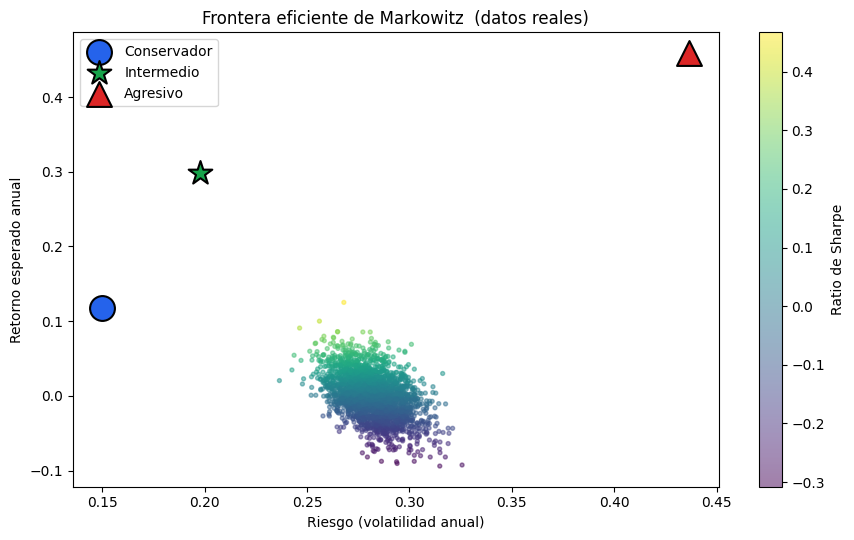

In [22]:
# =====================================================
# 📊 GRÁFICO 1 — FRONTERA EFICIENTE DE MARKOWITZ
# =====================================================
# Dibujamos miles de carteras al azar (nube de puntos) y marcamos las TRES óptimas.
# El color es el Sharpe: cuanto más arriba-izquierda, mejor (más retorno, menos riesgo).
# Ejemplo de lectura: el punto "Conservador" queda abajo-izquierda (poco riesgo) y
# el "Agresivo" arriba-derecha (mucho retorno y mucho riesgo).

np.random.seed(0)
N = 2500                                       # cantidad de carteras al azar
rets_sim = np.zeros(N); vols_sim = np.zeros(N)
for i in range(N):
    w = np.random.random(noa); w /= w.sum()    # pesos al azar que suman 1
    rets_sim[i] = port_ret(w)
    vols_sim[i] = port_vol(w)

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(vols_sim, rets_sim, c=rets_sim / vols_sim, cmap='viridis', s=8, alpha=0.5)
plt.colorbar(sc, label='Ratio de Sharpe')

estilos = {'conservador': ('o', '#2563eb'),
           'intermedio':  ('*', '#16a34a'),
           'agresivo':    ('^', '#dc2626')}
for perfil, w in PESOS.items():
    marcador, color = estilos[perfil]
    ax.scatter(port_vol(w), port_ret(w), marker=marcador, s=320, c=color,
               edgecolors='black', linewidths=1.5, label=perfil.capitalize(), zorder=5)

ax.set_xlabel('Riesgo (volatilidad anual)')
ax.set_ylabel('Retorno esperado anual')
ax.set_title(f'Frontera eficiente de Markowitz  (datos {FUENTE_DATOS})')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# =====================================================
# 5) ¿CUÁLES SON LAS MEJORES ACCIONES PARA TU PERFIL?
# =====================================================
# Hasta acá optimizamos sobre las 30 acciones juntas. Acá hacemos algo distinto:
# RANKEAMOS las acciones una por una según el criterio de cada perfil.
# - Conservador -> menor volatilidad (menos riesgo).
# - Intermedio  -> mejor Sharpe (mejor relación retorno/riesgo).
# - Agresivo    -> mayor retorno esperado.

# Métricas por activo (a partir de los retornos ya calculados)
metricas = pd.DataFrame({
    'retorno':     log_returns.mean() * 252,         # retorno anual esperado
    'volatilidad': log_returns.std() * np.sqrt(252)  # riesgo anual
})
metricas['sharpe'] = metricas['retorno'] / metricas['volatilidad']

def ranking(perfil):
    """Ordena TODAS las acciones según el criterio del perfil."""
    if perfil == 'conservador':
        return metricas.sort_values('volatilidad', ascending=True)   # menor riesgo primero
    if perfil == 'agresivo':
        return metricas.sort_values('retorno', ascending=False)      # mayor retorno primero
    return metricas.sort_values('sharpe', ascending=False)           # intermedio: mejor Sharpe

def mejores_tickers(perfil, n=10):
    """Devuelve la lista de los n mejores tickers para ese perfil."""
    return list(ranking(perfil).head(n).index)

# Vista rápida: los mejores N de cada perfil, lado a lado
N = 8
shortlist = pd.DataFrame({
    'Conservador (menor riesgo)': mejores_tickers('conservador', N),
    'Intermedio (mejor Sharpe)':  mejores_tickers('intermedio',  N),
    'Agresivo (mayor retorno)':   mejores_tickers('agresivo',    N),
}, index=[f'{i+1}º' for i in range(N)])
print('Top de acciones por perfil:')
shortlist

Top de acciones por perfil:


,Conservador (menor riesgo),Intermedio (mejor Sharpe),Agresivo (mayor retorno)
1º,IBN,ET,SMCI
2º,BMY,SAN,UAMY
3º,T,PBR-A,SAN
4º,ET,T,PBR-A
5º,AGNC,PBR,KGC
6º,HST,ITUB,ET
7º,ITUB,SMCI,PBR
8º,LYG,KGC,ITUB


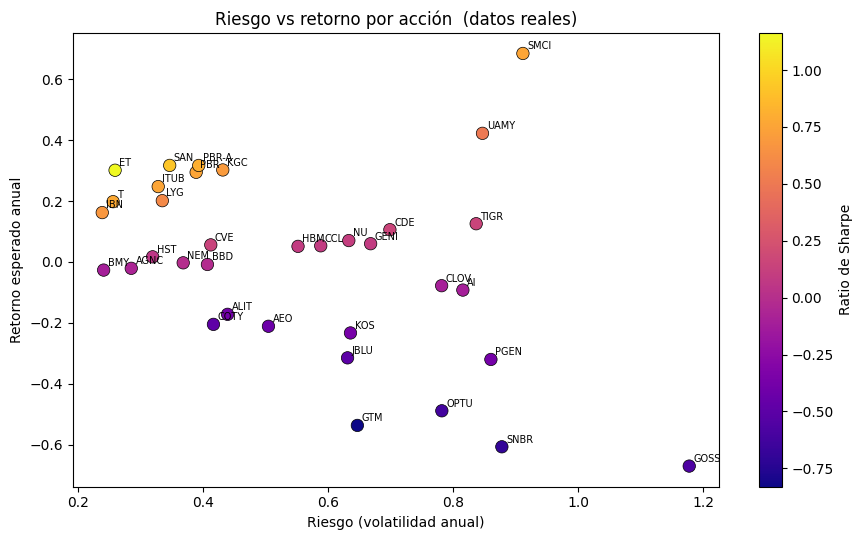

In [24]:
# =====================================================
# 📊 GRÁFICO 2 — CADA ACCIÓN: RIESGO vs RETORNO
# =====================================================
# Cada punto es una acción. Eje X = riesgo, eje Y = retorno, color = Sharpe.
# Ejemplo de lectura: las acciones arriba-izquierda son las "mejores" (más retorno
# con menos riesgo); las de abajo-derecha, las menos atractivas.

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(metricas['volatilidad'], metricas['retorno'], c=metricas['sharpe'],
                cmap='plasma', s=80, edgecolors='black', linewidths=0.5)
plt.colorbar(sc, label='Ratio de Sharpe')
for t in metricas.index:                          # etiqueta con el ticker
    ax.annotate(t, (metricas.loc[t, 'volatilidad'], metricas.loc[t, 'retorno']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Riesgo (volatilidad anual)')
ax.set_ylabel('Retorno esperado anual')
ax.set_title(f'Riesgo vs retorno por acción  (datos {FUENTE_DATOS})')
plt.tight_layout()
plt.show()

In [25]:
# =====================================================
# 5.1) ARMAR LA CARTERA USANDO SOLO LAS MEJORES ACCIONES DEL PERFIL
# =====================================================
# Esta función toma los n mejores tickers del perfil y optimiza la cartera SOLO con
# ellos (cartera más concentrada que la de la Sección 4, que usa las 30 acciones).
# Ejemplo de aplicación: cartera_de_mejores('intermedio', n=8, capital=10000)
# arma la cartera de máximo Sharpe con las 8 mejores acciones para ese perfil.

def cartera_de_mejores(perfil, n=8, capital=10000):
    sel = mejores_tickers(perfil, n)          # los n mejores tickers del perfil
    sub = log_returns[sel]                    # nos quedamos solo con esas columnas
    S   = sub.cov() * 252
    k   = len(sel)

    def ret(w): w = np.asarray(w, float); return float(np.sum(sub.mean() * w) * 252)
    def vol(w): w = np.asarray(w, float); return float(np.sqrt(w @ S.values @ w))

    # El objetivo depende del perfil (mismo criterio que en la Sección 4)
    if   perfil == 'conservador': objetivo = vol                       # minimizar riesgo
    elif perfil == 'agresivo':    objetivo = lambda w: -ret(w)         # maximizar retorno
    else:                         objetivo = lambda w: -ret(w) / vol(w) # maximizar Sharpe

    w_max = max(0.30, 1.0 / k)
    r = sco.minimize(objetivo, np.array(k * [1.0 / k]), method='SLSQP',
                     bounds=tuple((0.0, w_max) for _ in range(k)),
                     constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    w       = r.x
    precios = data.iloc[-1]                   # últimos precios para pasar a nominales

    print(f'CARTERA {perfil.upper()} con los {n} mejores tickers  ·  capital ${capital:,.2f}')
    print(f'Retorno {ret(w)*100:.1f}%  |  Riesgo {vol(w)*100:.1f}%  |  Sharpe {ret(w)/vol(w):.2f}')
    print('-' * 56)
    total = 0.0
    for t, p in pd.Series(w, index=sel).sort_values(ascending=False).items():
        if p > 0.005:                         # ignoramos pesos casi nulos
            monto  = capital * p
            total += monto
            print(f'  {t:6s} {p*100:5.1f}%   ${monto:9,.2f}   '
                  f'{monto/precios[t]:8.4f} nominales')
    print('-' * 56)
    print(f'  Total asignado: ${total:,.2f}')

# Ejemplo: probá cambiando el perfil, n y capital
cartera_de_mejores('intermedio', n=8, capital=10000)

CARTERA INTERMEDIO con los 8 mejores tickers  ·  capital $10,000.00
Retorno 30.4%  |  Riesgo 20.3%  |  Sharpe 1.49
--------------------------------------------------------
  ET      30.0%   $ 3,000.00   179.8654 nominales
  T       27.4%   $ 2,735.94   104.4768 nominales
  SAN     14.2%   $ 1,421.02   186.5812 nominales
  PBR-A   10.3%   $ 1,033.86    96.2060 nominales
  SMCI     7.5%   $   753.63    17.1436 nominales
  KGC      6.9%   $   686.77    50.2587 nominales
  ITUB     3.7%   $   368.78    62.5003 nominales
--------------------------------------------------------
  Total asignado: $10,000.00


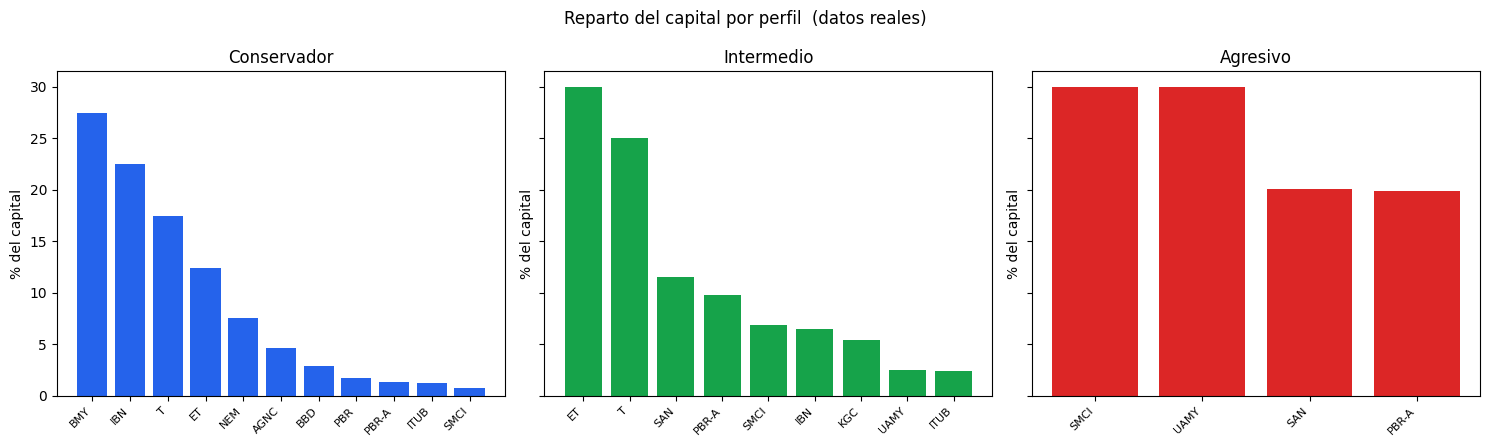

In [26]:
# =====================================================
# 📊 GRÁFICO 3 — PESOS DE LA CARTERA POR PERFIL
# =====================================================
# Un gráfico de barras por perfil: qué % del capital va a cada acción (usando las
# carteras de la Sección 4). Se ve clarito que el conservador reparte entre muchas
# acciones (menos riesgo) y el agresivo concentra en pocas (más riesgo/retorno).

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (perfil, w) in zip(axes, PESOS.items()):
    s = pd.Series(w, index=mean_ret.index)
    s = s[s > 0.005].sort_values(ascending=False)     # solo pesos relevantes
    ax.bar(range(len(s)), s.values * 100, color=estilos[perfil][1])
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(perfil.capitalize())
    ax.set_ylabel('% del capital')
fig.suptitle(f'Reparto del capital por perfil  (datos {FUENTE_DATOS})')
plt.tight_layout()
plt.show()

In [27]:
# =====================================================
# 6) ▶️ LA APP (preguntas por consola)
# =====================================================
# Ejecutá esta celda. Hace TRES preguntas (cuánto dinero, qué tipo de inversor y
# cuántas acciones querés) y arma la cartera óptima usando SOLO los mejores tickers
# del perfil (los de la Sección 5).
# Ejemplo de uso: monto 15000, opción 1 (reacio al riesgo), 6 acciones
# -> arma la cartera más conservadora con 6 acciones, repartiendo los $15.000.

PERFILES = {
    '1': ('conservador', 'Reacio al riesgo       → prioriza minimizar el riesgo'),
    '2': ('intermedio',  'Intermedio             → mejor equilibrio riesgo/retorno'),
    '3': ('agresivo',    'Dispuesto a arriesgar  → busca el máximo retorno'),
}

# --- Pregunta 1: ¿cuánto dinero? ---
while True:
    try:
        capital = float(input('💸 ¿Cuánto dinero querés invertir? (ej. 10000): ')
                        .strip().replace(',', ''))
        if capital > 0:
            break
        print('❌ Ingresá un monto mayor a 0.')
    except ValueError:
        print('❌ Solo números, por favor (ej. 10000).')

# --- Pregunta 2: ¿qué tipo de inversor sos? ---
print('\n¿Qué tipo de inversor sos?')
for k, (_, desc) in PERFILES.items():
    print(f'   {k}) {desc}')
while True:
    opcion = input('Elegí 1, 2 o 3: ').strip()
    if opcion in PERFILES:
        break
    print('❌ Opción inválida. Elegí 1, 2 o 3.')
perfil, _ = PERFILES[opcion]

# --- Pregunta 3: ¿cuántas acciones querés en la cartera? ---
while True:
    try:
        n_acciones = int(input(f'¿Cuántas acciones querés en la cartera? (entre 2 y {noa}): ').strip())
        if 2 <= n_acciones <= noa:
            break
        print(f'❌ Elegí un número entre 2 y {noa}.')
    except ValueError:
        print('❌ Ingresá un número entero (ej. 8).')

# --- Resultado: optimiza usando SOLO los mejores n tickers del perfil ---
print()
cartera_de_mejores(perfil, n=n_acciones, capital=capital)

💸 ¿Cuánto dinero querés invertir? (ej. 10000): 1000000

¿Qué tipo de inversor sos?
   1) Reacio al riesgo       → prioriza minimizar el riesgo
   2) Intermedio             → mejor equilibrio riesgo/retorno
   3) Dispuesto a arriesgar  → busca el máximo retorno
Elegí 1, 2 o 3: 1
¿Cuántas acciones querés en la cartera? (entre 2 y 35): 17

CARTERA CONSERVADOR con los 17 mejores tickers  ·  capital $1,000,000.00
Retorno 11.4%  |  Riesgo 15.0%  |  Sharpe 0.76
--------------------------------------------------------
  BMY     27.2%   $271,780.30   6229.2204 nominales
  IBN     22.8%   $228,319.29   6766.4792 nominales
  T       17.2%   $172,009.11   6568.4700 nominales
  ET      12.9%   $128,865.78   7726.1643 nominales
  NEM      7.5%   $75,414.81   1536.3857 nominales
  AGNC     5.1%   $51,054.00   6555.6958 nominales
  BBD      2.7%   $27,239.69   10400.4767 nominales
  PBR-A    1.6%   $16,286.69   1515.5636 nominales
  PBR      1.5%   $15,428.68   1361.9388 nominales
  ITUB     1.4%   $1

In [28]:
# =====================================================
# 7) LA APP CON BOTONES E INTERFAZ
# =====================================================
# Si tu Jupyter / Google Colab soporta ipywidgets, esta versión es más "app":
# elegís el monto, el perfil y el número de acciones con controles visuales y
# apretás un botón. Hace lo mismo que la Sección 6.
# Si no muestra controles, usá la Sección 6 (funciona en cualquier entorno).

import ipywidgets as widgets
from IPython.display import display, clear_output

w_capital = widgets.FloatText(
    value=10000, description='Capital $:',
    style={'description_width': 'initial'})

w_perfil = widgets.RadioButtons(
    options=[('Reacio al riesgo (conservador)', 'conservador'),
             ('Intermedio (equilibrado)',       'intermedio'),
             ('Dispuesto a arriesgar (agresivo)','agresivo')],
    description='Perfil:',
    style={'description_width': 'initial'})

w_n = widgets.IntSlider(
    value=8, min=2, max=noa, step=1,
    description='N° acciones:',
    style={'description_width': 'initial'},
    continuous_update=False)

boton  = widgets.Button(description='Calcular cartera', button_style='success', icon='check')
salida = widgets.Output()

def calcular(_):
    with salida:
        clear_output()
        capital = float(w_capital.value)
        if capital <= 0:
            print('Ingresá un capital mayor a 0.')
            return
        # Misma función que el resto de la notebook
        cartera_de_mejores(w_perfil.value, n=int(w_n.value), capital=capital)

boton.on_click(calcular)
display(w_capital, w_perfil, w_n, boton, salida)

FloatText(value=10000.0, description='Capital $:', style=DescriptionStyle(description_width='initial'))

RadioButtons(description='Perfil:', options=(('Reacio al riesgo (conservador)', 'conservador'), ('Intermedio (…

IntSlider(value=8, continuous_update=False, description='N° acciones:', max=35, min=2, style=SliderStyle(descr…

Button(button_style='success', description='Calcular cartera', icon='check', style=ButtonStyle())

Output()

In [29]:
# =====================================================
# 8) BÚSQUEDA AVANZADA EN YAHOO: TU PROPIO FILTRO POR PERFIL
# =====================================================
# En vez de los screeners "de fábrica" de la Sección 2, acá armás un filtro A MEDIDA
# con EquityQuery, traduciendo el perfil a criterios concretos (capitalización + liquidez).
# Si tu versión de yfinance no soporta algún campo, la función cae sola al screener de la 2.
#
# 💡 CÓMO USARLO: generá un universo a medida y volvé a correr desde la Sección 2
#    (paso 2) en adelante para rehacer el análisis y los gráficos con ese universo:
#       tickers = buscar_tickers_avanzado('agresivo', size=30)
#       # luego re-ejecutá "PASO 2", "3) CÁLCULOS", "4) CARTERAS", etc.

from yfinance import EquityQuery as Q


def buscar_tickers_avanzado(perfil, size=40, region='us'):
    """Arma un screener a medida según el perfil (capitalización + liquidez).
       Si el filtro a medida falla (los campos cambian entre versiones), cae al de la 2."""
    perfil = perfil.lower()
    if perfil == 'conservador':            # grandes y líquidas -> menos riesgo
        consulta = Q('and', [Q('eq', ['region', region]),
                             Q('gt', ['intradaymarketcap', 50_000_000_000]),
                             Q('gt', ['avgdailyvol3m', 1_000_000])])
    elif perfil == 'agresivo':             # chicas/medianas -> más riesgo/retorno
        consulta = Q('and', [Q('eq', ['region', region]),
                             Q('gt', ['intradaymarketcap', 300_000_000]),
                             Q('lt', ['intradaymarketcap', 10_000_000_000]),
                             Q('gt', ['avgdailyvol3m', 300_000])])
    else:                                  # medianas-grandes y líquidas -> equilibrio
        consulta = Q('and', [Q('eq', ['region', region]),
                             Q('gt', ['intradaymarketcap', 10_000_000_000]),
                             Q('lt', ['intradaymarketcap', 200_000_000_000]),
                             Q('gt', ['avgdailyvol3m', 1_000_000])])
    try:
        syms = _simbolos_de(yf.screen(consulta, size=size))
        if syms:
            return syms[:size]
    except Exception as e:
        print('  (aviso) el filtro a medida falló, uso el screener de la Sección 2:', e)
    return buscar_tickers_yahoo(perfil, size=size)   # respaldo seguro


# Ejemplo: ver el universo a medida para el perfil agresivo (solo si hay yfinance)
if HAY_YFINANCE:
    try:
        print('Universo a medida (agresivo):', buscar_tickers_avanzado('agresivo', size=10))
    except Exception as e:
        print('No se pudo ejecutar la búsqueda avanzada:', e)
else:
    print('⚠️ Esta sección necesita yfinance / internet.')


Universo a medida (agresivo): ['ZYME', 'ZWS', 'ZVRA', 'ZURA', 'ZNOG', 'ZLAB', 'ZION', 'ZIM', 'ZGN', 'ZG']


In [30]:
# =====================================================
# 9) EXPORTAR A PDF: CARTERA (nominales y costo) + GR\u00c1FICOS DE AN\u00c1LISIS
# =====================================================
# Arma un PDF de varias p\u00e1ginas con TODO el entregable visual:
#   P\u00e1gina 1 -> la cartera elegida: cu\u00e1nto poner en cada acci\u00f3n, su COSTO en US$,
#               el precio unitario y los NOMINALES (cantidad de acciones a comprar).
#   P\u00e1ginas 2-4 -> los 3 gr\u00e1ficos del an\u00e1lisis (frontera, riesgo-retorno y pesos).
# Usa solo matplotlib (PdfPages): NO hay que instalar nada en Colab.
# \U0001F449 Ejemplo de aplicaci\u00f3n:
#       exportar_cartera_pdf('intermedio', n=8, capital=10000)
#   -> crea "cartera_intermedio.pdf" y, si est\u00e1s en Colab, lo descarga solo.

from matplotlib.backends.backend_pdf import PdfPages
from datetime import date

# Colores por perfil (los mismos que usan los gr\u00e1ficos de arriba)
_ESTILOS = {'conservador': ('o', '#2563eb'),
            'intermedio':  ('*', '#16a34a'),
            'agresivo':    ('^', '#dc2626')}


def cartera_detallada(perfil, n=8, capital=10000):
    """Optimiza con las n mejores acciones del perfil y devuelve (tabla, metricas).
       tabla: DataFrame con Acci\u00f3n, % capital, Costo (US$), Precio (US$) y Nominales."""
    perfil = perfil.lower()
    sel = mejores_tickers(perfil, n)
    sub = log_returns[sel]
    S   = sub.cov() * 252
    k   = len(sel)
    def ret(w): w = np.asarray(w, float); return float(np.sum(sub.mean() * w) * 252)
    def vol(w): w = np.asarray(w, float); return float(np.sqrt(w @ S.values @ w))
    if   perfil == 'conservador': objetivo = vol                        # minimizar riesgo
    elif perfil == 'agresivo':    objetivo = lambda w: -ret(w)          # maximizar retorno
    else:                         objetivo = lambda w: -ret(w) / vol(w)  # maximizar Sharpe
    w_max = max(0.30, 1.0 / k)
    r = sco.minimize(objetivo, np.array(k * [1.0 / k]), method='SLSQP',
                     bounds=tuple((0.0, w_max) for _ in range(k)),
                     constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    w       = r.x
    precios = data.iloc[-1]
    filas = []
    for t, p in pd.Series(w, index=sel).sort_values(ascending=False).items():
        if p > 0.005:                                  # ignoramos pesos casi nulos
            costo = capital * p
            filas.append({'Acci\u00f3n': t,
                          '% capital':   p * 100,
                          'Costo (US$)': costo,
                          'Precio (US$)': float(precios[t]),
                          'Nominales':   costo / float(precios[t])})
    tabla = pd.DataFrame(filas)
    metr  = {'retorno': ret(w), 'vol': vol(w), 'sharpe': ret(w) / vol(w),
             'total': float(tabla['Costo (US$)'].sum())}
    return tabla, metr


# --- Las 3 figuras del an\u00e1lisis (mismo dibujo que las secciones de arriba) -------
def _fig_frontera():
    np.random.seed(0)
    M = 2500
    rs = np.zeros(M); vs = np.zeros(M)
    for i in range(M):
        w = np.random.random(noa); w /= w.sum()
        rs[i] = port_ret(w); vs[i] = port_vol(w)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sc = ax.scatter(vs, rs, c=rs / vs, cmap='viridis', s=8, alpha=0.5)
    fig.colorbar(sc, label='Ratio de Sharpe')
    for perfil, w in PESOS.items():
        m, c = _ESTILOS[perfil]
        ax.scatter(port_vol(w), port_ret(w), marker=m, s=320, c=c,
                   edgecolors='black', linewidths=1.5, label=perfil.capitalize(), zorder=5)
    ax.set_xlabel('Riesgo (volatilidad anual)'); ax.set_ylabel('Retorno esperado anual')
    ax.set_title(f'Frontera eficiente de Markowitz  (datos {FUENTE_DATOS})')
    ax.legend(); fig.tight_layout()
    return fig


def _fig_riesgo_retorno():
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sc = ax.scatter(metricas['volatilidad'], metricas['retorno'], c=metricas['sharpe'],
                    cmap='plasma', s=80, edgecolors='black', linewidths=0.5)
    fig.colorbar(sc, label='Ratio de Sharpe')
    for t in metricas.index:
        ax.annotate(t, (metricas.loc[t, 'volatilidad'], metricas.loc[t, 'retorno']),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Riesgo (volatilidad anual)'); ax.set_ylabel('Retorno esperado anual')
    ax.set_title(f'Riesgo vs retorno por acci\u00f3n  (datos {FUENTE_DATOS})')
    fig.tight_layout()
    return fig


def _fig_pesos():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, (perfil, w) in zip(axes, PESOS.items()):
        s = pd.Series(w, index=mean_ret.index)
        s = s[s > 0.005].sort_values(ascending=False)
        ax.bar(range(len(s)), s.values * 100, color=_ESTILOS[perfil][1])
        ax.set_xticks(range(len(s)))
        ax.set_xticklabels(s.index, rotation=45, ha='right', fontsize=8)
        ax.set_title(perfil.capitalize()); ax.set_ylabel('% del capital')
    fig.suptitle(f'Reparto del capital por perfil  (datos {FUENTE_DATOS})')
    fig.tight_layout()
    return fig


def _fig_tabla(perfil, tabla, metr, capital):
    """P\u00e1gina 1 del PDF: encabezado + tabla de la cartera (costo y nominales)."""
    fig = plt.figure(figsize=(8.27, 11.69))                  # A4 vertical
    fig.suptitle('Cartera de inversi\u00f3n sugerida', fontsize=18, fontweight='bold', y=0.96)
    fig.text(0.5, 0.915, f'Perfil: {perfil.capitalize()}    \u00b7    '
             f'Capital: US$ {capital:,.2f}    \u00b7    {date.today().isoformat()}',
             ha='center', fontsize=11)
    fig.text(0.5, 0.89, f'Fuente de datos: {FUENTE_DATOS}', ha='center', fontsize=9, color='gray')
    fig.text(0.5, 0.855, f'Retorno esperado anual: {metr["retorno"]*100:.1f}%       '
             f'Riesgo: {metr["vol"]*100:.1f}%       Sharpe: {metr["sharpe"]:.2f}',
             ha='center', fontsize=10)

    ax = fig.add_axes([0.07, 0.42, 0.86, 0.38]); ax.axis('off')
    vis = tabla.copy()
    vis['% capital']    = vis['% capital'].map(lambda x: f'{x:.1f}%')
    vis['Costo (US$)']  = vis['Costo (US$)'].map(lambda x: f'{x:,.2f}')
    vis['Precio (US$)'] = vis['Precio (US$)'].map(lambda x: f'{x:,.2f}')
    vis['Nominales']    = vis['Nominales'].map(lambda x: f'{x:,.4f}')
    t = ax.table(cellText=vis.values, colLabels=list(vis.columns),
                 cellLoc='center', loc='upper center')
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.6)
    for j in range(len(vis.columns)):                        # encabezado coloreado
        c = t[0, j]; c.set_facecolor(_ESTILOS[perfil][1])
        c.set_text_props(color='white', fontweight='bold')

    fig.text(0.5, 0.37, f'Total asignado: US$ {metr["total"]:,.2f}',
             ha='center', fontsize=13, fontweight='bold')
    fig.text(0.5, 0.04, 'Generado con la App de Inversi\u00f3n \u2014 Modelo de Markowitz.  '
             'Material educativo: no constituye recomendaci\u00f3n de inversi\u00f3n.',
             ha='center', fontsize=8, color='gray')
    return fig


def exportar_cartera_pdf(perfil='intermedio', n=8, capital=10000, archivo=None):
    """Crea un PDF con la cartera (costo + nominales) y los 3 gr\u00e1ficos de an\u00e1lisis."""
    perfil = perfil.lower()
    tabla, metr = cartera_detallada(perfil, n, capital)
    archivo = archivo or f'cartera_{perfil}.pdf'
    with PdfPages(archivo) as pdf:
        for fabricar in (lambda: _fig_tabla(perfil, tabla, metr, capital),
                         _fig_frontera, _fig_riesgo_retorno, _fig_pesos):
            fig = fabricar(); pdf.savefig(fig); plt.close(fig)

    print(f'\u2705 PDF generado: {archivo}  ({n} acciones, perfil {perfil}, capital US$ {capital:,.2f})')
    print(tabla.assign(**{'% capital':   tabla['% capital'].map('{:.1f}%'.format),
                          'Costo (US$)': tabla['Costo (US$)'].map('{:,.2f}'.format),
                          'Precio (US$)': tabla['Precio (US$)'].map('{:,.2f}'.format),
                          'Nominales':   tabla['Nominales'].map('{:,.4f}'.format)})
          .to_string(index=False))
    print(f'Total asignado: US$ {metr["total"]:,.2f}')

    try:                                   # en Google Colab, descarga el archivo solo
        from google.colab import files
        files.download(archivo)
    except Exception:
        print('(Si est\u00e1s en Colab y no se descarg\u00f3 solo, busc\u00e1lo en el panel de Archivos \U0001F4C1)')
    return archivo


# Ejemplo de aplicaci\u00f3n: cambi\u00e1 perfil ('conservador'/'intermedio'/'agresivo'), n y capital
exportar_cartera_pdf('intermedio', n=8, capital=10000)


✅ PDF generado: cartera_intermedio.pdf  (8 acciones, perfil intermedio, capital US$ 10,000.00)
Acción % capital Costo (US$) Precio (US$) Nominales
    ET     30.0%    3,000.00        16.68  179.8654
     T     27.4%    2,735.94        26.19  104.4768
   SAN     14.2%    1,421.02         7.62  186.5812
 PBR-A     10.3%    1,033.86        10.75   96.2060
  SMCI      7.5%      753.63        43.96   17.1436
   KGC      6.9%      686.77        13.66   50.2587
  ITUB      3.7%      368.78         5.90   62.5003
Total asignado: US$ 10,000.00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'cartera_intermedio.pdf'